# 02 — Pipeline de dados

Construímos e **validamos** o pipeline `tf.data` antes de treinar qualquer modelo. Decisões-chave:

- **Split 70/15/15** (treino/validação/teste), determinístico via fatiamento percentual do tfds — mesma ordem em todos os experimentos.
- **Normalização por banda (z-score)**: média e desvio calculados **só no treino** e reusados em val/test (evita vazamento de dados). Salvos em `results/norm_stats.json` para os notebooks de treino.
- **Data augmentation** apropriada para imagens aéreas: flips horizontal/vertical e rotações de 90°. **Sem** color jitter ou rotação contínua — alterariam as assinaturas espectrais.

As estatísticas de normalização cobrem as 13 bandas; cada modelo seleciona depois o subconjunto de canais que usa.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from src import config
from src import data_loader as dl
from src import visualization as viz

config.ensure_dirs()
tf.random.set_seed(config.SEED); np.random.seed(config.SEED)

I0000 00:00:1780156623.125432    5893 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Criar os splits

`make_splits` retorna 3 datasets disjuntos com (imagem `(64,64,13)` float32, label int).

In [2]:
train_ds, val_ds, test_ds = dl.make_splits()

n_train = int(train_ds.reduce(0, lambda c, _: c + 1))
n_val = int(val_ds.reduce(0, lambda c, _: c + 1))
n_test = int(test_ds.reduce(0, lambda c, _: c + 1))
print(f'treino={n_train}  validação={n_val}  teste={n_test}  total={n_train+n_val+n_test}')

I0000 00:00:1780156628.094075    5893 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6
I0000 00:00:1780156628.773932    6651 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


treino=18900  validação=4050  teste=4050  total=27000


## 2. Normalização por banda

Calculamos média/desvio por banda **no conjunto de treino** e salvamos em disco. Os 3 notebooks de treino carregam esse mesmo arquivo — garantindo normalização idêntica.

In [3]:
mean, std = dl.compute_norm_stats(train_ds)
dl.save_norm_stats(mean, std)
print('Salvo em:', config.NORM_STATS_PATH)

import pandas as pd
pd.DataFrame({'banda': config.BAND_NAMES, 'média': mean.round(1), 'desvio': std.round(1)})

Salvo em: results/norm_stats.json


,banda,média,desvio
0,B1,1353.300049,245.600006
1,B2,1117.000000,334.500000
2,B3,1042.199951,396.200012
3,B4,946.500000,595.599976
4,B5,1199.900024,567.200012
5,B6,2007.400024,860.900024
6,B7,2380.199951,1087.599976
7,B8,2307.399902,1119.000000
8,B8A,733.799988,403.500000
9,B9,12.100000,4.700000


## 3. Montar o pipeline e validar um batch

Usamos os índices RGB+NIR só para inspeção visual. Após a normalização, cada banda deve ter média ≈ 0 e desvio ≈ 1.

In [4]:
channels = config.RGB_NIR_INDICES
train_pipe = dl.build_pipeline(train_ds, channels, mean, std, augment=True, shuffle=True)
val_pipe = dl.build_pipeline(val_ds, channels, mean, std, augment=False, shuffle=False)

xb, yb = next(iter(train_pipe))
print('batch x:', xb.shape, xb.dtype, '| y:', yb.shape)
print('média do batch por canal:', xb.numpy().mean(axis=(0,1,2)).round(2))
print('desvio do batch por canal:', xb.numpy().std(axis=(0,1,2)).round(2))

batch x: (64, 64, 64, 4) <dtype: 'float32'> | y: (64,)
média do batch por canal: [-0.04 -0.05 -0.04 -0.1 ]
desvio do batch por canal: [0.98 0.98 0.93 1.03]


W0000 00:00:1780156670.374514    7107 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node augmentation_1/random_flip_1/Add/ReadVariableOp/_2}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
W0000 00:00:1780156670.374527    7111 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node augmentation_1/random_flip_1/Add/_6}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
W0000 00:00:1780156670.385998    5893 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 4. Visualizar augmentation

Mostramos a mesma imagem passada várias vezes pela camada de augmentation. Esperado: flips e rotações de 90° — a cena muda de orientação, mas as cores/assinaturas espectrais permanecem intactas.

> Desfazemos a normalização só para exibição (a augmentation real roda sobre os dados normalizados).

W0000 00:00:1780156670.936277    5893 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


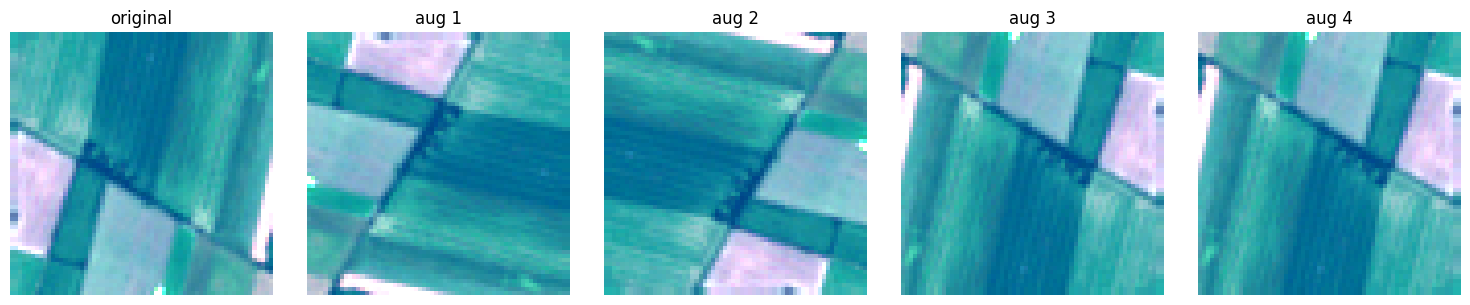

In [5]:
aug = dl.get_augmentation_layer()
mean_sel = np.asarray(mean)[channels]; std_sel = np.asarray(std)[channels]

# Uma única imagem normalizada (sem augmentation), replicada num batch.
raw = next(iter(val_pipe))[0][0:1]  # (1,64,64,4) normalizada

def denorm_rgb(x):
    x = x.numpy()[0] * std_sel + mean_sel        # desfaz z-score
    rgb = x[..., :3]                              # B4,B3,B2
    lo, hi = np.percentile(rgb, 2), np.percentile(rgb, 98)
    return np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(denorm_rgb(raw)); axes[0].set_title('original'); axes[0].axis('off')
for i in range(1, 5):
    augmented = aug(raw, training=True)
    axes[i].imshow(denorm_rgb(augmented)); axes[i].set_title(f'aug {i}'); axes[i].axis('off')
plt.tight_layout()
plt.show()

## Conclusão

- Splits disjuntos e determinísticos criados.
- Normalização por banda verificada (média≈0, desvio≈1) e **salva em `results/norm_stats.json`**.
- Augmentation preserva as assinaturas espectrais.

O pipeline está pronto. **Próximo passo:** `03_train_model_a_rgb.ipynb`.